In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset 
import torch.nn.functional as F
from sklearn.metrics import accuracy_score



In [2]:
iris=load_iris()
X=torch.tensor(iris.data , dtype=torch.float32)
y=torch.tensor(iris.target , dtype=torch.long)



In [3]:
from sklearn.model_selection import train_test_split   
X_train , X_test , y_train , y_test=train_test_split(X , y , test_size=0.3 , random_state=101)

train_data=TensorDataset(X_train , y_train)
test_data=TensorDataset(X_test , y_test)

#now dataloader 

train_loader=DataLoader(train_data , batch_size=20 ,drop_last=True ,  shuffle=True)
test_loader=DataLoader(test_data , batch_size=test_data.tensors[0].shape[0] , shuffle=False)



In [4]:
class ANNmodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input=nn.Linear(4 , 20)
        self.output=nn.Linear(20 , 4)
        self.dr=nn.Dropout(0.25)
        
    def forward(self , x):
        x=self.input(x)
        x=F.relu(x)
        x=self.dr(x)
        x=F.leaky_relu(x)
        x=self.output(x)
        
        return x
    
    

In [5]:
#now we def the model 
def definemodel():
    model=ANNmodel()
    lossfn=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters() , lr=0.005 )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100)
    
    return optimizer , lossfn , model , scheduler

def trainmodel(model , optimizer , lossfn , scheduler):
    train_acc=[]
    
    test_acc=[]
    epochs=1000
    model.train()
    for i in range(epochs):
        acc_per_batch=[]
        for X, y in train_loader:
            y_train_preds=model(X)
            loss=lossfn(y_train_preds , y)
            
            l1_term=torch.tensor(0. , requires_grad=True)
            l2_term=torch.tensor(0. , requires_grad=True)
            
            for name, weights in model.named_parameters():
                 if 'bias' not in name:
                     l1_term=l1_term+torch.sum(torch.abs(weights))
                     l2_term=l2_term+torch.sum((weights**2))
                     
            lambda_l1 = 1e-5
            lambda_l2 = 1e-4

            loss = loss + lambda_l1*l1_term + lambda_l2*l2_term
            
            
            #backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            labels=torch.argmax(y_train_preds , dim=1)
            acc_per_batch.append(accuracy_score(labels , y))
            
        scheduler.step()
         #now train_acc
        train_acc.append(np.mean(acc_per_batch))
        
        model.eval()
        for X , y in test_loader :
            y_pred=model(X)
            labels = torch.argmax(y_pred, dim=1)
            test_acc.append(accuracy_score(labels , y))
            
    return test_acc , train_acc 
            
            
            
    
  


In [6]:
optimizer , lossfn , model , scheduler = definemodel()

In [7]:
test_acc , train_acc =trainmodel(model , optimizer  , lossfn , scheduler)




In [8]:
for name, param in model.named_parameters():
    if 'bias' not in name:
       print(name, param.shape)

input.weight torch.Size([20, 4])
output.weight torch.Size([4, 20])


In [9]:
print(len(train_acc))

1000


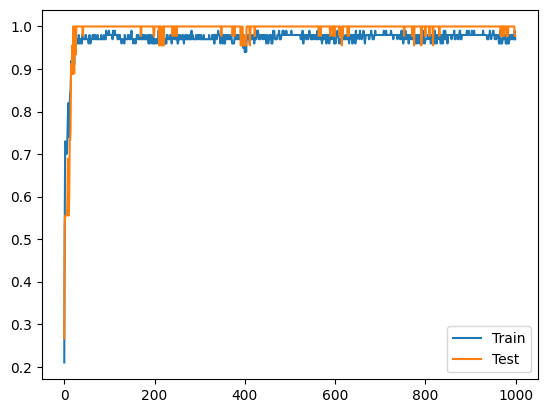

In [10]:
epochs=1000
plt.plot(range(epochs) , train_acc)
plt.plot(range(epochs) , test_acc)
plt.legend(['Train','Test'])
